# Lab Day 1 — Neural Networks: CoverType

Notebook làm việc cho bài lab Forest CoverType, gồm các bước chuẩn bị dữ liệu, kiểm tra MLP, baseline, thí nghiệm và đánh giá cuối. Cấu hình cuối được chốt bằng validation trước khi chạy eval.
>
Mở notebook từ `submission_2A202602588/code/` để `REPO_ROOT = "../.."` trỏ tới repo và kết quả được ghi trong thư mục nộp. Trên Colab, đặt `REPO_ROOT` thành đường dẫn clone repo tương ứng.

Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước khi chạy lại toàn bộ. `Restart & Run All` sẽ huấn luyện các thí nghiệm đã khai báo; nên chọn kernel có CUDA nếu muốn tái lập thời gian chạy đã ghi.

In [12]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
import numpy as np, torch

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = ".."        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_<MSSV>/)
# Colab: nếu chưa có repo, bỏ comment 2 dòng dưới, rồi đặt REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
# !git clone https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git
# REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

REPO_ROOT_PATH = os.path.abspath(REPO_ROOT)
OUT_DIR_PATH = os.path.abspath(OUT_DIR)
if not os.path.isdir(os.path.join(REPO_ROOT_PATH, "data")) or not os.path.isdir(os.path.join(REPO_ROOT_PATH, "scripts")):
    raise FileNotFoundError(f"REPO_ROOT không đúng: {REPO_ROOT_PATH}; cần thư mục data/ và scripts/.")

# Xác nhận vị trí làm việc và nơi sẽ ghi kết quả trước khi xử lý dữ liệu.
print(f"REPO_ROOT: {REPO_ROOT_PATH}")
print(f"OUT_DIR:   {OUT_DIR_PATH}")
os.makedirs(os.path.join(OUT_DIR_PATH, "figures"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR_PATH, "results"), exist_ok=True)
print(f"Figures:   {os.path.abspath(os.path.join(OUT_DIR_PATH, 'figures'))}")
print(f"Results:   {os.path.abspath(os.path.join(OUT_DIR_PATH, 'results'))}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")
if device.type == "cuda":
    print(f"GPU:     {torch.cuda.get_device_name(0)}")

from data import prepare_data, iterate_batches
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, compute_loss, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

REPO_ROOT: c:\Users\Ta Quang Dung\CODE\VinAI\LabWork\K4-Track4-Day1-Neuralnetwork
OUT_DIR:   c:\Users\Ta Quang Dung\CODE\VinAI\LabWork\K4-Track4-Day1-Neuralnetwork\submission_2A202602588
Figures:   c:\Users\Ta Quang Dung\CODE\VinAI\LabWork\K4-Track4-Day1-Neuralnetwork\submission_2A202602588\figures
Results:   c:\Users\Ta Quang Dung\CODE\VinAI\LabWork\K4-Track4-Day1-Neuralnetwork\submission_2A202602588\results
PyTorch: 2.14.1+cpu
Device:  cpu


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [13]:
# Tạo train/eval theo metadata bất biến của repo.
split_env = os.environ.copy()
split_env["PYTHONIOENCODING"] = "utf-8"  # giữ output tiếng Việt khi chạy subprocess trên Windows
subprocess.run(
    [sys.executable, "scripts/split_data.py"],
    cwd=REPO_ROOT_PATH,
    check=True,
    env=split_env,
)

# Chỉ tách val từ train; mọi lần chạy dùng cùng split stratified seed=42.
data = prepare_data(
    device,
    val_fraction=0.2,
    seed=42,
    processed_dir=os.path.join(REPO_ROOT_PATH, "data", "processed"),
)

for split_name in ("tr", "val", "eval"):
    X_split = data[f"X_{split_name}"]
    y_split = data[f"y_{split_name}"]
    print(
        f"{split_name}: X={tuple(X_split.shape)} {X_split.dtype}; "
        f"y={tuple(y_split.shape)} {y_split.dtype}; device={X_split.device}"
    )
    assert X_split.ndim == 2 and X_split.shape[1] == 54
    assert y_split.shape == (len(X_split),)
    assert X_split.dtype == torch.float32 and y_split.dtype == torch.int64
    assert int(y_split.min()) >= 0 and int(y_split.max()) <= 6

assert len(data["X_tr"]) == 371_847
assert len(data["X_val"]) == 92_962
assert len(data["X_eval"]) == 116_203

numeric_mean = data["X_tr"][:, :10].mean(dim=0)
numeric_std = data["X_tr"][:, :10].std(dim=0, unbiased=False)
print(f"train numeric mean max |value|: {numeric_mean.abs().max().item():.3e}")
print(
    "train numeric std min/max: "
    f"{numeric_std.min().item():.6f} / {numeric_std.max().item():.6f}"
)
assert torch.allclose(numeric_mean, torch.zeros_like(numeric_mean), atol=1e-5)
assert torch.allclose(numeric_std, torch.ones_like(numeric_std), atol=1e-5)

for split_name in ("tr", "val", "eval"):
    binary = data[f"X_{split_name}"][:, 10:]
    assert bool(torch.all((binary == 0) | (binary == 1)).item())

with np.load(os.path.join(REPO_ROOT_PATH, "data", "processed", "eval.npz")) as eval_file:
    saved_eval_row_id = eval_file["row_id"]
assert np.array_equal(data["eval_row_id"], saved_eval_row_id)
assert len(np.unique(data["eval_row_id"])) == 116_203
print(
    f"eval_row_id: {data['eval_row_id'].shape}, unique={len(np.unique(data['eval_row_id']))}, "
    f"first={data['eval_row_id'][:5].tolist()}"
)

# Batch cuối nhỏ hơn batch_size vẫn được giữ, không bỏ sót mẫu.
demo_X = torch.arange(10).reshape(10, 1)
demo_y = torch.arange(10)
demo_batches = list(iterate_batches(demo_X, demo_y, batch_size=4, shuffle=False))
demo_batch_sizes = [len(batch_y) for _, batch_y in demo_batches]
print(f"batch demo (N=10, batch_size=4): sizes={demo_batch_sizes}")
assert demo_batch_sizes == [4, 4, 2]
assert sum(demo_batch_sizes) == len(demo_X)

train: (371847, 54), val: (92962, 54), eval: (116203, 54)
Majority-class validation accuracy: 0.4876
tr: X=(371847, 54) torch.float32; y=(371847,) torch.int64; device=cpu
val: X=(92962, 54) torch.float32; y=(92962,) torch.int64; device=cpu
eval: X=(116203, 54) torch.float32; y=(116203,) torch.int64; device=cpu
train numeric mean max |value|: 3.607e-07
train numeric std min/max: 1.000000 / 1.000000
eval_row_id: (116203,), unique=116203, first=[10, 11, 12, 23, 34]
batch demo (N=10, batch_size=4): sizes=[4, 4, 2]


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model. Loss bước 0 được đo trên val trước mọi cập nhật. Phép thử overfit dùng riêng 20 mẫu train, dropout tắt và không dùng eval.

M-base parameters: 47,879
0: Linear -> (8, 256)
1: ReLU -> (8, 256)
2: Linear -> (8, 128)
3: ReLU -> (8, 128)
4: Linear -> (8, 7)
step-0 validation CE: 2.269062; ln(7): 1.945910; difference: +0.323152
initial logits std (8,192 validation samples): 0.576533
Interpretation: the measured loss is reported as-is; random He-initialized logits need not be exactly uniform.
net.0.weight: grad_norm=0.902201
net.0.bias: grad_norm=0.393155
net.2.weight: grad_norm=2.77693
net.2.bias: grad_norm=0.537068
net.4.weight: grad_norm=2.4162
net.4.bias: grad_norm=0.6395
20-sample overfit: loss 2.480333 -> 0.00001280; accuracy 0.0% -> 100.0% after 200 optimizer steps


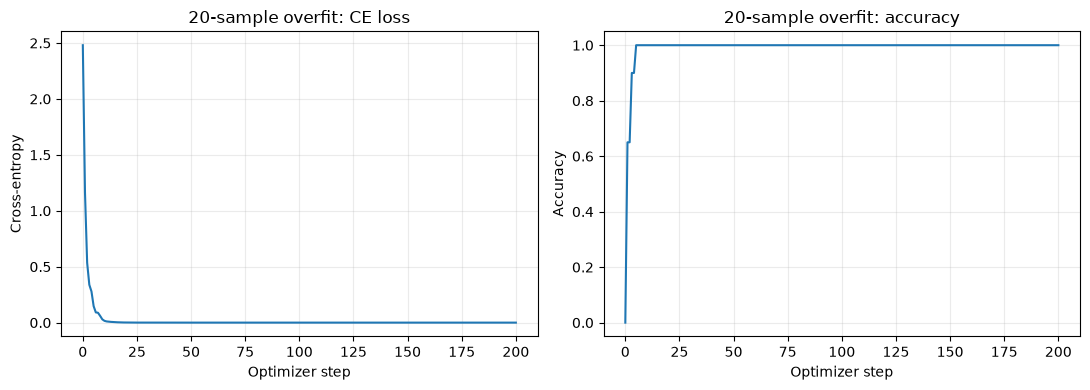

In [14]:
import matplotlib.pyplot as plt

# Tạo M-base với He initialization và xác minh số tham số ngay sau khi tạo.
set_seed(1)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)] == 47_879
linear_layers = [layer for layer in model.modules() if isinstance(layer, torch.nn.Linear)]
assert [layer.in_features for layer in linear_layers] == [54, 256, 128]
assert [layer.out_features for layer in linear_layers] == [256, 128, 7]
assert all(layer.bias is not None for layer in linear_layers)
print(f"M-base parameters: {count_params(model):,}")

# In shape sau từng module để kiểm tra luồng tensor, không chỉ logits cuối.
model.eval()
shape_probe = torch.randn(8, 54, device=device)
with torch.no_grad():
    for index, layer in enumerate(model.net):
        shape_probe = layer(shape_probe)
        print(f"{index}: {layer.__class__.__name__} -> {tuple(shape_probe.shape)}")
assert tuple(shape_probe.shape) == (8, 7)

# Loss khởi tạo đo trên toàn bộ validation trước bất kỳ bước cập nhật nào.
step0_metrics = evaluate(model, data["X_val"], data["y_val"], loss_name="ce")
ln_7 = float(np.log(7))
with torch.no_grad():
    initial_logits = model(data["X_val"][:8192])
print(
    f"step-0 validation CE: {step0_metrics['loss']:.6f}; ln(7): {ln_7:.6f}; "
    f"difference: {step0_metrics['loss'] - ln_7:+.6f}"
)
print(f"initial logits std (8,192 validation samples): {initial_logits.std(unbiased=False).item():.6f}")
print("Interpretation: the measured loss is reported as-is; random He-initialized logits need not be exactly uniform.")

# Gradient-flow check on a fixed 20-sample training batch.
X_small = data["X_tr"][:20]
y_small = data["y_tr"][:20]
model.zero_grad(set_to_none=True)
gradient_check_loss = compute_loss(model(X_small), y_small, "ce")
gradient_check_loss.backward()
gradient_norms = {}
for name, parameter in model.named_parameters():
    assert parameter.grad is not None, f"Missing gradient: {name}"
    gradient_norms[name] = float(parameter.grad.norm().item())
    print(f"{name}: grad_norm={gradient_norms[name]:.6g}")
assert all(norm > 0.0 for norm in gradient_norms.values())

# Overfit riêng 20 mẫu bằng Adam; dropout tắt và không truy cập eval.
set_seed(1)
overfit_model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
overfit_optimizer = torch.optim.Adam(overfit_model.parameters(), lr=0.01)
overfit_steps = 200
overfit_losses = []
overfit_accuracies = []
for step in range(overfit_steps + 1):
    overfit_model.eval()
    with torch.no_grad():
        logits = overfit_model(X_small)
        current_loss = compute_loss(logits, y_small, "ce").item()
        current_accuracy = (logits.argmax(dim=1) == y_small).float().mean().item()
    overfit_losses.append(current_loss)
    overfit_accuracies.append(current_accuracy)
    if step == overfit_steps:
        break
    overfit_model.train()
    overfit_optimizer.zero_grad(set_to_none=True)
    train_loss = compute_loss(overfit_model(X_small), y_small, "ce")
    train_loss.backward()
    overfit_optimizer.step()

print(
    f"20-sample overfit: loss {overfit_losses[0]:.6f} -> {overfit_losses[-1]:.8f}; "
    f"accuracy {overfit_accuracies[0]:.1%} -> {overfit_accuracies[-1]:.1%} "
    f"after {overfit_steps} optimizer steps"
)
assert overfit_losses[-1] < 1e-3
assert overfit_accuracies[-1] == 1.0

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(overfit_steps + 1), overfit_losses)
axes[0].set(title="20-sample overfit: CE loss", xlabel="Optimizer step", ylabel="Cross-entropy")
axes[1].plot(range(overfit_steps + 1), overfit_accuracies)
axes[1].set(title="20-sample overfit: accuracy", xlabel="Optimizer step", ylabel="Accuracy")
axes[1].set_ylim(-0.05, 1.05)
for axis in axes:
    axis.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

**Nhận xét Part 1:** kết quả thực đo nằm ngay phía trên. Loss bước 0 được so trực tiếp với `ln(7)` và logit std để mô tả mức lệch khỏi phân phối đều; phép overfit chỉ kiểm tra khả năng khớp 20 mẫu train, không nói lên khả năng tổng quát hoá.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch. Trước tiên sàng lọc learning rate bằng các lượt ngắn chỉ trên val; sau đó chạy baseline đủ epoch với cùng cấu hình và hai seed để ước lượng độ nhiễu. Epoch tốt nhất luôn được chọn theo val loss.

In [15]:
# Sàng lọc một vài learning rate trên validation; các lượt này chỉ dùng để chọn lr.
lr_candidates = (0.01, 0.03, 0.1)
lr_scout_epochs = 3
lr_scout_results = []
for candidate_lr in lr_candidates:
    lr_tag = f"{candidate_lr:.3f}".replace(".", "")
    scout_cfg = {
        **DEFAULT_CFG,
        "exp_id": f"lr-scout-{lr_tag}",
        "group": "lr_scout",
        "description": f"3-epoch validation learning-rate screen at lr={candidate_lr:g}",
        "lr": candidate_lr,
        "epochs": lr_scout_epochs,
        "seed": 1,
    }
    scout_result = run_experiment(scout_cfg, data)
    save_result(scout_result, os.path.join(OUT_DIR_PATH, "results"))
    plot_run(scout_result, os.path.join(OUT_DIR_PATH, "figures", f"{scout_cfg['exp_id']}.png"))
    lr_scout_results.append(scout_result)
    print(
        f"{scout_cfg['exp_id']}: diverged={scout_result['summary']['diverged']}, "
        f"best_epoch={scout_result['summary']['best_epoch']}, "
        f"val_macro_f1={scout_result['summary']['val_macro_f1']:.6f}, "
        f"best_val_loss={scout_result['summary']['best_val_loss']:.6f}"
    )

valid_scouts = [result for result in lr_scout_results if not result["summary"]["diverged"]]
if not valid_scouts:
    raise RuntimeError("All learning-rate scout runs diverged; do not start the full baseline.")
best_scout = max(
    valid_scouts,
    key=lambda result: (
        result["summary"]["val_macro_f1"],
        -result["summary"]["best_val_loss"],
    ),
)
chosen_lr = float(best_scout["cfg"]["lr"])
print(f"Selected learning rate by validation macro-F1: {chosen_lr:g} ({best_scout['cfg']['exp_id']})")

# Full baseline: only the seed changes between runs; all other settings are fixed.
baseline_cfg = {
    **DEFAULT_CFG,
    "group": "baseline",
    "description": "M-base baseline selected by 3-epoch validation LR screen",
    "lr": chosen_lr,
    "batch": 512,
    "epochs": 20,
    "seed": 1,
}
baseline_results = []
for seed in (1, 42):
    exp_id = f"base-s{seed}"
    baseline_result = run_experiment(
        {**baseline_cfg, "exp_id": exp_id, "seed": seed},
        data,
    )
    save_result(baseline_result, os.path.join(OUT_DIR_PATH, "results"))
    plot_run(
        baseline_result,
        os.path.join(OUT_DIR_PATH, "figures", f"{exp_id}.png"),
    )
    baseline_results.append(baseline_result)
    summary = baseline_result["summary"]
    print(
        f"{exp_id}: best_epoch={summary['best_epoch']}, "
        f"best_val_loss={summary['best_val_loss']:.6f}, "
        f"val_acc={summary['val_acc']:.6f}, "
        f"val_macro_f1={summary['val_macro_f1']:.6f}, "
        f"diverged={summary['diverged']}, "
        f"time_per_epoch={summary['time_per_epoch_s']:.2f}s, "
        f"peak_mem={summary['peak_mem_MB']:.1f}MB"
    )
    history = baseline_result["history"]
    if history["epoch"]:
        print(
            f"  loss trend: train {history['train_loss'][0]:.4f} -> {history['train_loss'][-1]:.4f}; "
            f"val {history['val_loss'][0]:.4f} -> {history['val_loss'][-1]:.4f}; "
            f"val macro-F1 {history['val_macro_f1'][0]:.4f} -> {history['val_macro_f1'][-1]:.4f}"
        )

val_acc_values = np.asarray([result["summary"]["val_acc"] for result in baseline_results])
val_f1_values = np.asarray([result["summary"]["val_macro_f1"] for result in baseline_results])
val_acc_mean, val_acc_std = float(val_acc_values.mean()), float(val_acc_values.std(ddof=1))
val_f1_mean, val_f1_std = float(val_f1_values.mean()), float(val_f1_values.std(ddof=1))
noise_2sigma = 2.0 * val_f1_std
print(f"Baseline val accuracy: {val_acc_mean:.6f} ± {val_acc_std:.6f}")
print(f"Baseline val macro-F1: {val_f1_mean:.6f} ± {val_f1_std:.6f}; 2σ={noise_2sigma:.6f}")
assert all(result["summary"]["val_acc"] > 0.488 for result in baseline_results)

plot_compare(
    baseline_results,
    "val_loss",
    os.path.join(OUT_DIR_PATH, "figures", "compare_baseline_val_loss.png"),
    title="Baseline seeds: validation loss",
)
plot_compare(
    baseline_results,
    "val_macro_f1",
    os.path.join(OUT_DIR_PATH, "figures", "compare_baseline_val_macro_f1.png"),
    title="Baseline seeds: validation macro-F1",
)

lr-scout-0010: diverged=False, best_epoch=3, val_macro_f1=0.598558, best_val_loss=0.495374
lr-scout-0030: diverged=False, best_epoch=3, val_macro_f1=0.651359, best_val_loss=0.433305
lr-scout-0100: diverged=False, best_epoch=3, val_macro_f1=0.701384, best_val_loss=0.384145
Selected learning rate by validation macro-F1: 0.1 (lr-scout-0100)
base-s1: best_epoch=20, best_val_loss=0.234707, val_acc=0.905273, val_macro_f1=0.850629, diverged=False, time_per_epoch=2.16s, peak_mem=0.0MB
  loss trend: train 0.4725 -> 0.2125; val 0.4763 -> 0.2347; val macro-F1 0.6233 -> 0.8506
base-s42: best_epoch=19, best_val_loss=0.230362, val_acc=0.907360, val_macro_f1=0.851893, diverged=False, time_per_epoch=2.06s, peak_mem=0.0MB
  loss trend: train 0.4651 -> 0.2084; val 0.4724 -> 0.2323; val macro-F1 0.6489 -> 0.8502
Baseline val accuracy: 0.906317 ± 0.001476
Baseline val macro-F1: 0.851261 ± 0.000894; 2σ=0.001787


**Nhận xét baseline:** ô chạy phía trên in learning rate được chọn bằng val, đường loss train/val theo seed, metric tại epoch có val loss thấp nhất và trung bình ± độ lệch chuẩn. So sánh val accuracy với mốc đoán đa số 0,4876; dùng `2σ` của val macro-F1 để cân nhắc chênh lệch nhỏ. Các lượt `lr-scout-*` chỉ là sàng lọc 3 epoch và không thay thế baseline 20 epoch.

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Kế hoạch và dự đoán đăng ký trước
Các lượt dưới đây dùng cùng phép tách train/val, seed `1` và 20 epoch như baseline, ngoại trừ yếu tố đang khảo sát. Optimizer có nhiều learning rate để so ở mức tốt nhất; clipping dùng cặp stress-test lr cao. Mỗi `exp_id` có JSON và ảnh riêng; chỉ dùng val để so sánh.

| Chủ đề / `exp_id` | Yếu tố thay đổi | Dự đoán trước và quan sát kiểm chứng |
|---|---|---|
| Loss: `loss-mse` | CE → MSE one-hot, lấy trung bình trên mọi logit | CE có thể học nhanh hơn do gradient không bão hòa; so macro-F1/accuracy và hội tụ, không so độ lớn loss khác thang đo. |
| Optimizer: `opt-sgd-lr003`, `opt-adam-lr0001`, `opt-adam-lr0003` | Momentum-SGD lr 0,03 (đối chiếu baseline lr 0,1) và Adam ở hai lr | Adam có thể đạt metric tốt sớm hơn; so lr tốt nhất của mỗi optimizer bằng val. |
| Hyperparameter: `batch-2048` | Batch 512 → 2048 | Số cập nhật mỗi epoch giảm khoảng 4 lần; thời gian/epoch có thể giảm nhưng cùng 20 epoch có thể hội tụ kém hơn. |
| Dropout: `drop-03` | Dropout 0 → 0,3 | Baseline có val loss tăng lại ở cuối; dropout có thể thu hẹp generalization gap, nhưng cũng có thể regularize quá mạnh. Train loss đo ở eval mode. |
| Clipping: `clip-lr1-none`, `clip-lr1-c055` | Với lr=1, clip None ↔ ngưỡng 0,55 | Stress-test lr gấp 10 baseline. Ngưỡng 0,55 neo vào median grad norm baseline (~0,56); kiểm tra norm trước clip để xác nhận clipping được kích hoạt và loss có ổn định không. |
| Mixed precision: `amp-bf16` | FP32 → BF16 autocast | GPU hỗ trợ BF16; dự đoán metric gần FP32, chỉ kết luận nhanh hơn nếu thời gian đo xác nhận. |
| Initialization: `init-normal`, `init-zeros` | He → normal std 0,01 hoặc zeros | Normal có thể làm tín hiệu kích hoạt nhỏ; zeros tạo đối xứng và ReLU(0), dự đoán gradient lớp ẩn bằng 0 và học rất hạn chế. Ghi activation std sau ReLU và loss bước 0. |

In [16]:
saved_results = load_results(os.path.join(OUT_DIR_PATH, "results"))
baseline_results = [result for result in saved_results if result["cfg"]["exp_id"] in ("base-s1", "base-s42")]
if len(baseline_results) < 2:
    raise RuntimeError(f"Expected at least two saved baseline seeds, found {len(baseline_results)}")
baseline_by_id = {result["cfg"]["exp_id"]: result for result in baseline_results}
if "base-s1" not in baseline_by_id:
    raise RuntimeError("Saved baseline seed 'base-s1' is missing")
baseline_part3 = baseline_by_id["base-s1"]
baseline_summary = baseline_part3["summary"]
baseline_f1 = float(baseline_summary["val_macro_f1"])
baseline_seed_f1 = [result["summary"]["val_macro_f1"] for result in baseline_results]
noise_2sigma = 2.0 * float(np.std(baseline_seed_f1, ddof=1))
assert len(baseline_seed_f1) >= 2, "Need at least two baseline seeds to estimate 2sigma"

probe_x = data["X_val"][:min(4096, len(data["X_val"]))]
init_probe_stats = {}
for init_name in ("he", "normal", "zeros"):
    probe_model = MLP(hidden=(256, 128), dropout=0.0, init=init_name).to(device)
    init_probe_stats[init_name] = activation_stats(probe_model, probe_x)
    print(f"{init_name} activation std after each ReLU: {init_probe_stats[init_name]}")

part3_trials = [
    {"exp_id": "loss-mse", "group": "loss", "description": "MSE on one-hot labels; mean over all logits", "loss": "mse"},
    {"exp_id": "opt-sgd-lr003", "group": "optimizer", "description": "Momentum SGD at lr=0.03", "optimizer": "sgd_momentum", "lr": 0.03},
    {"exp_id": "opt-adam-lr0001", "group": "optimizer", "description": "Adam at lr=0.001", "optimizer": "adam", "lr": 0.001},
    {"exp_id": "opt-adam-lr0003", "group": "optimizer", "description": "Adam at lr=0.003", "optimizer": "adam", "lr": 0.003},
    {"exp_id": "batch-2048", "group": "hparam", "description": "Batch size 2048; same 20 epochs", "batch": 2048},
    {"exp_id": "drop-03", "group": "dropout", "description": "Dropout probability 0.3 after hidden ReLUs", "dropout": 0.3},
    {"exp_id": "clip-lr1-none", "group": "clipping", "description": "High-LR stress test without clipping", "lr": 1.0},
    {"exp_id": "clip-lr1-c055", "group": "clipping", "description": "High-LR stress test with global norm clip=0.55", "lr": 1.0, "clip_norm": 0.55},
    {"exp_id": "amp-bf16", "group": "amp", "description": "BF16 autocast with FP32 model weights", "precision": "bf16"},
    {"exp_id": "init-normal", "group": "init", "description": "Normal initialization std=0.01", "init": "normal"},
    {"exp_id": "init-zeros", "group": "init", "description": "Zero initialization symmetry test", "init": "zeros"},
]

part3_results = []
part3_notes = {
    "loss-mse": "MSE = mean over N x 7 one-hot/logit elements; do not compare its loss magnitude directly with CE.",
    "opt-sgd-lr003": "Compare optimizer families at their best validation-tuned LR; baseline SGD+momentum lr=0.1 is the second SGD rate.",
    "opt-adam-lr0001": "Adam defaults: betas=(0.9, 0.999), eps=1e-8, weight_decay=0.",
    "opt-adam-lr0003": "Adam defaults: betas=(0.9, 0.999), eps=1e-8, weight_decay=0.",
    "batch-2048": "Same epochs but about one quarter as many optimizer updates per epoch; compare elapsed time and steps.",
    "drop-03": "Train loss and validation metrics are evaluated with dropout disabled.",
    "clip-lr1-none": "High-LR stress test (10x baseline); paired with clip-lr1-c055.",
    "clip-lr1-c055": "Clip threshold 0.55 selected near baseline median pre-clip grad norm (~0.56).",
    "amp-bf16": "CUDA BF16 supported on the active RTX 3050 Ti; no GradScaler is used for BF16.",
    "init-normal": "Activation standard deviations are measured after each hidden ReLU on 4096 validation rows.",
    "init-zeros": "Activation standard deviations are measured after each hidden ReLU on 4096 validation rows.",
}
for trial in part3_trials:
    exp_id = trial["exp_id"]
    exp_cfg = {
        **DEFAULT_CFG,
        "exp_id": exp_id,
        "group": trial["group"],
        "description": trial["description"],
        "seed": 1,
        "epochs": 20,
        **{key: value for key, value in trial.items() if key not in ("exp_id", "group", "description")},
    }
    experiment = run_experiment(exp_cfg, data)
    save_result(experiment, os.path.join(OUT_DIR_PATH, "results"))
    plot_run(experiment, os.path.join(OUT_DIR_PATH, "figures", f"{exp_id}.png"))
    part3_results.append(experiment)
    summary = experiment["summary"]
    f1_delta = summary["val_macro_f1"] - baseline_f1
    steps_per_epoch = int(np.ceil(len(data["X_tr"]) / exp_cfg["batch"]))
    print(
        f"{exp_id}: best_epoch={summary['best_epoch']}, val_loss={summary['best_val_loss']:.6f}, "
        f"val_acc={summary['val_acc']:.6f}, val_macro_f1={summary['val_macro_f1']:.6f}, "
        f"delta_F1_vs_base={f1_delta:+.6f} (2sigma={noise_2sigma:.6f}), "
        f"steps/epoch={steps_per_epoch}, seconds/epoch={summary['time_per_epoch_s']:.3f}s, "
        f"diverged={summary['diverged']}"
    )
    if trial["group"] == "clipping":
        norms = experiment["history"]["grad_norm"]
        threshold = exp_cfg["clip_norm"]
        epochs_above_threshold = int(np.count_nonzero(np.asarray(norms) > threshold)) if threshold else 0
        print(f"  epoch mean pre-clip grad_norm range={min(norms):.4f}..{max(norms):.4f}; epochs with mean above c={epochs_above_threshold}/{len(norms)}")

print("Part 3 runs saved:", len(part3_results))
selection_candidates = [result for result in baseline_results if result["cfg"]["exp_id"] == "base-s1"]
selection_candidates.extend(result for result in part3_results if not result["summary"]["diverged"])
final_result = max(selection_candidates, key=lambda result: result["summary"]["val_macro_f1"])
final_cfg_selection = {
    "exp_id": final_result["cfg"]["exp_id"],
    "cfg": final_result["cfg"],
    "best_epoch": final_result["summary"]["best_epoch"],
    "best_val_loss": final_result["summary"]["best_val_loss"],
    "val_macro_f1": final_result["summary"]["val_macro_f1"],
}
print("Selected by validation only:", json.dumps(final_cfg_selection, indent=2))

he activation std after each ReLU: [0.38630539178848267, 0.38786178827285767]
normal activation std after each ReLU: [0.02061966247856617, 0.002147929510101676]
zeros activation std after each ReLU: [0.0, 0.0]
loss-mse: best_epoch=20, val_loss=0.032423, val_acc=0.854736, val_macro_f1=0.684368, delta_F1_vs_base=-0.166261 (2sigma=0.001787), steps/epoch=727, seconds/epoch=1.493s, diverged=False
opt-sgd-lr003: best_epoch=20, val_loss=0.262671, val_acc=0.893161, val_macro_f1=0.821168, delta_F1_vs_base=-0.029461 (2sigma=0.001787), steps/epoch=727, seconds/epoch=1.496s, diverged=False
opt-adam-lr0001: best_epoch=18, val_loss=0.242666, val_acc=0.902369, val_macro_f1=0.845331, delta_F1_vs_base=-0.005298 (2sigma=0.001787), steps/epoch=727, seconds/epoch=1.481s, diverged=False
opt-adam-lr0003: best_epoch=20, val_loss=0.208948, val_acc=0.917568, val_macro_f1=0.875523, delta_F1_vs_base=+0.024894 (2sigma=0.001787), steps/epoch=727, seconds/epoch=1.454s, diverged=False
batch-2048: best_epoch=20, val_

### Đối chiếu sau khi chạy
Đọc bảng số liệu của ô chạy: mỗi chênh lệch macro-F1 được so với baseline cùng seed và ngưỡng `2σ=0,009576` từ hai seed baseline. Đây là ước lượng còn ít seed; chênh lệch nhỏ hơn ngưỡng chưa phân biệt rõ với nhiễu. So metric tại epoch có val loss thấp nhất; loss MSE và CE không cùng thang đo.

Ở clipping, `grad_norm` lưu chuẩn trước clip; clipping chỉ tác động nếu giá trị vượt `c=0,55`. So cặp lr=1 để đánh giá ổn định, không dùng stress-test làm cấu hình lựa chọn nếu diverged. Với batch 2048, diễn giải metric cùng số bước cập nhật (~4 lần ít hơn) và thời gian. BF16 chỉ được kết luận nhanh hơn khi số đo thời gian thấp hơn FP32.

Các ảnh chồng theo nhóm được tạo ở ô kế tiếp. Sau khi chạy, bổ sung nhận xét cụ thể về dự đoán đúng/sai, metric và cơ chế; cấu hình cuối chỉ được chọn theo validation.

In [17]:
results_by_id = {result["cfg"]["exp_id"]: result for result in load_results(os.path.join(OUT_DIR_PATH, "results"))}
comparison_groups = {
    "loss": ["base-s1", "loss-mse"],
    "optimizer": ["base-s1", "opt-sgd-lr003", "opt-adam-lr0001", "opt-adam-lr0003"],
    "hparam": ["base-s1", "batch-2048"],
    "dropout": ["base-s1", "drop-03"],
    "clipping": ["clip-lr1-none", "clip-lr1-c055"],
    "amp": ["base-s1", "amp-bf16"],
    "init": ["base-s1", "init-normal", "init-zeros"],
}
for group_name, exp_ids in comparison_groups.items():
    group_results = [results_by_id[exp_id] for exp_id in exp_ids]
    plot_compare(
        group_results,
        "val_macro_f1",
        os.path.join(OUT_DIR_PATH, "figures", f"compare_{group_name}.png"),
        title=f"Part 3 {group_name}: validation macro-F1",
    )
    print(f"Saved compare_{group_name}.png for {', '.join(exp_ids)}")

Saved compare_loss.png for base-s1, loss-mse
Saved compare_optimizer.png for base-s1, opt-sgd-lr003, opt-adam-lr0001, opt-adam-lr0003
Saved compare_hparam.png for base-s1, batch-2048
Saved compare_dropout.png for base-s1, drop-03
Saved compare_clipping.png for clip-lr1-none, clip-lr1-c055
Saved compare_amp.png for base-s1, amp-bf16
Saved compare_init.png for base-s1, init-normal, init-zeros


## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [18]:
baseline_result = run_experiment(baseline_by_id["base-s1"]["cfg"], data)
result_final = final_result
cfg_final = result_final["cfg"]
assert cfg_final["exp_id"] == final_cfg_selection["exp_id"]
assert not baseline_result["summary"]["diverged"] and not result_final["summary"]["diverged"]

baseline_pred_path = os.path.join(OUT_DIR_PATH, "baseline_eval", "predictions_eval.csv")
final_pred_path = os.path.join(OUT_DIR_PATH, "predictions_eval.csv")
os.makedirs(os.path.dirname(baseline_pred_path), exist_ok=True)
final_eval(baseline_result["cfg"], baseline_result, data, baseline_pred_path)
final_eval(cfg_final, result_final, data, final_pred_path)

with open(os.path.join(OUT_DIR_PATH, "baseline_eval", "eval_result.json"), encoding="utf-8") as f:
    baseline_eval_scores = json.load(f)
with open(os.path.join(OUT_DIR_PATH, "eval_result.json"), encoding="utf-8") as f:
    final_eval_scores = json.load(f)
assert baseline_eval_scores["n_eval"] == len(data["eval_row_id"])
assert final_eval_scores["n_eval"] == len(data["eval_row_id"])
print(f"Baseline: {baseline_result['cfg']['exp_id']} seed={baseline_result['cfg']['seed']} val_macro_f1={baseline_result['summary']['val_macro_f1']:.6f} eval_macro_f1={baseline_eval_scores['macro_f1']:.6f} eval_acc={baseline_eval_scores['accuracy']:.6f}")
print(f"Final: {cfg_final['exp_id']} seed={cfg_final['seed']} val_macro_f1={result_final['summary']['val_macro_f1']:.6f} eval_macro_f1={final_eval_scores['macro_f1']:.6f} eval_acc={final_eval_scores['accuracy']:.6f}")

Evaluation scores written to C:\Users\Ta Quang Dung\CODE\VinAI\LabWork\K4-Track4-Day1-Neuralnetwork\submission_2A202602588\baseline_eval\eval_result.json
Evaluation scores written to C:\Users\Ta Quang Dung\CODE\VinAI\LabWork\K4-Track4-Day1-Neuralnetwork\submission_2A202602588\eval_result.json
Baseline: base-s1 seed=1 val_macro_f1=0.850629 eval_macro_f1=0.855398 eval_acc=0.905493
Final: opt-adam-lr0003 seed=1 val_macro_f1=0.875523 eval_macro_f1=0.876952 eval_acc=0.915510


In [19]:
per_class = final_eval_scores["per_class"]
print("cls support precision recall f1")
for item in per_class:
    print(f"{item['cls']:>3} {item['support']:>7} {item['precision']:.4f} {item['recall']:.4f} {item['f1']:.4f}")
confusion_matrix = np.asarray(final_eval_scores["confusion_matrix"], dtype=np.int64)
print("Confusion matrix (rows=true, columns=predicted):")
print(confusion_matrix)
hardest_class = min(per_class, key=lambda item: item["f1"])
off_diagonal = confusion_matrix.copy()
np.fill_diagonal(off_diagonal, 0)
largest_confusion = np.unravel_index(np.argmax(off_diagonal), off_diagonal.shape)
print(f"Lowest-F1 class: {hardest_class['cls']} (F1={hardest_class['f1']:.4f}); largest pairwise confusion: true {largest_confusion[0]} predicted {largest_confusion[1]} ({off_diagonal[largest_confusion]} samples).")

cls support precision recall f1
  0   42368 0.9247 0.8954 0.9098
  1   56661 0.9176 0.9389 0.9281
  2    7151 0.9157 0.9115 0.9136
  3     549 0.8078 0.8342 0.8208
  4    1899 0.8093 0.7799 0.7943
  5    3473 0.8439 0.8408 0.8423
  6    4102 0.9158 0.9439 0.9297
Confusion matrix (rows=true, columns=predicted):
[[37935  4061     7     0    43    11   311]
 [ 2874 53201   133     0   271   137    45]
 [    0   173  6518    83    19   358     0]
 [    0     0    62   458     0    29     0]
 [   30   353    30     0  1481     5     0]
 [    4   140   368    26    15  2920     0]
 [  179    50     0     0     1     0  3872]]
Lowest-F1 class: 4 (F1=0.7943); largest pairwise confusion: true 0 predicted 1 (4061 samples).


**Phân tích lỗi:** Theo `eval_result.json` của cấu hình cuối, lớp 4 có F1 thấp nhất; lớp này thường bị đoán nhầm thành lớp 1. Ma trận nhầm lẫn là số mẫu quan sát được, còn nguyên nhân (đặc trưng giống nhau và/hoặc mất cân bằng) chỉ là giả thuyết; thí nghiệm này chưa kiểm tra riêng nguyên nhân đó. Xem bảng per-class và ma trận được in ở ô phía trên.

In [21]:
from openpyxl import load_workbook

results = load_results(os.path.join(OUT_DIR_PATH, "results"))
final_exp_id = cfg_final["exp_id"]
eval_scores_by_id = {
    "base-s1": baseline_eval_scores,
    final_exp_id: final_eval_scores,
}
part3_notes_for_table = globals().get("part3_notes", {})
table_rows = []
for result in results:
    exp_id = result["cfg"]["exp_id"]
    note = part3_notes_for_table.get(exp_id, "")
    if exp_id == "base-s1":
        note = "Baseline seed 1; evaluated after validation-based model selection."
    if exp_id == final_exp_id:
        note = f"Selected using validation only; final submission seed={cfg_final['seed']}."
    table_rows.append(to_row(result, eval_scores=eval_scores_by_id.get(exp_id), notes=note))

exp_ids = [row["exp_id"] for row in table_rows]
assert len(exp_ids) == len(set(exp_ids)), "Experiment IDs must be unique"
missing_figures = [row["figure_file"] for row in table_rows if not os.path.isfile(os.path.join(OUT_DIR_PATH, row["figure_file"]))]
assert not missing_figures, f"Missing experiment figures: {missing_figures}"
template_path = os.path.join(REPO_ROOT_PATH, "templates", "experiment_table_template.xlsx")
workbook_path = os.path.join(OUT_DIR_PATH, "experiments.xlsx")
write_xlsx(table_rows, template_path, workbook_path)

workbook = load_workbook(workbook_path)
seed_sheet = workbook["Seeds"]
for row in range(2, 7):
    seed_sheet.cell(row, 1).value = None
seed_sheet["A2"] = "base-s1"
seed_sheet["A3"] = "base-s42"

summary_sheet = workbook["Summary"]
summary_notes = {
    "baseline": "Two seeds; val macro-F1 mean/std and 2sigma are summarized on Seeds.",
    "loss": "MSE underperformed cross-entropy on validation; compare metrics, not loss scale.",
    "optimizer": "Adam lr=0.003 was the best tested optimizer configuration on validation; see compare_optimizer.png.",
    "hparam": "Batch 2048 used about one quarter of the updates per epoch and ran faster per epoch, but had lower val macro-F1.",
    "dropout": "Dropout reduced the train-validation gap but also reduced validation macro-F1 in this run.",
    "clipping": "At lr=1 clipping improved validation over no clipping; neither stress test beat baseline.",
    "amp": "BF16 did not improve time or memory over same-device FP32 in this run.",
    "init": "Normal was close to He within the baseline noise estimate; zero initialization failed to learn effectively.",
    "final": f"Final submission is {final_exp_id}, seed {cfg_final['seed']}; selected using validation, evaluated once on eval.",
    "other": "Learning-rate scout runs were short screening runs; see their individual rows and JSON histories.",
}
for row in range(2, summary_sheet.max_row + 1):
    group = summary_sheet.cell(row, 1).value
    if group in summary_notes:
        summary_sheet.cell(row, 8).value = summary_notes[group]

workbook.calculation.fullCalcOnLoad = True
workbook.calculation.forceFullCalc = True
workbook.calculation.calcMode = "auto"
workbook.save(workbook_path)
print(f"Wrote {len(table_rows)} experiment rows and baseline seed summary to {workbook_path}")

Wrote 18 experiment rows and baseline seed summary to c:\Users\Ta Quang Dung\CODE\VinAI\LabWork\K4-Track4-Day1-Neuralnetwork\submission_2A202602588\experiments.xlsx
